# 4. Modelado con PySpark

Este capítulo corresponde a la sección 9.10.4.5 del proyecto. Se entrenan los mismos seis modelos con `pyspark.ml.classification`, con los mismos espacios de búsqueda y el mismo criterio de selección (ROC AUC). Se respetan todas las condiciones del enunciado:

* **Búsqueda de hiperparámetros:** exclusivamente con `ParamGridBuilder` y `CrossValidator(numFolds=3)`, sin bucles manuales sobre combinaciones.
* **Criterio de selección:** `BinaryClassificationEvaluator(metricName="areaUnderROC")`.
* **Configuración:** la `SparkSession` obligatoria (`spark.sql.shuffle.partitions=400`, `spark.default.parallelism=400`, `spark.driver.memory=8g`, …).
* **Datos:**
  * se lee el CSV completo;
  * se usa la partición común (`split.parquet`), no `randomSplit`;
  * los DataFrames se cachean después del `VectorAssembler`.
* **Transferencia al driver:** no se usa `.toPandas()` ni `.collect()` sobre el dataset. Solo al terminar el entrenamiento y la predicción se transfieren las columnas `id`, `default` y la puntuación del conjunto de prueba, y ese tiempo se reporta por separado.

**Dos decisiones de ejecución**, justificadas en la sección 4.6:

1. **12 particiones.** Los DataFrames de modelado se reducen con `coalesce` a **12 particiones**, una por núcleo lógico, antes de cachearlos. La configuración de la sesión no cambia.
2. **`cacheNodeIds=True`** en los modelos de árbol.

En una primera ejecución con las 400 particiones heredadas de `spark.sql.shuffle.partitions`, la regresión logística tardó 40 minutos y el árbol de decisión 31. El bosque aleatorio avanzó 7 de 27 ajustes en 1 h 38 min, hasta que la JVM se quedó sin memoria y se cayó. Además, **cada modelo se entrena en una sesión de Spark (JVM) nueva** y sus resultados se guardan al terminar, para que un fallo de memoria en un modelo no invalide los demás.

In [1]:
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark import StorageLevel
from pyspark.ml.classification import (DecisionTreeClassifier, GBTClassifier, LinearSVC, LogisticRegression,
                                       NaiveBayes, RandomForestClassifier)
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import functions as F

import lc_utils as U

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
U.SPARK_PARTIAL_DIR.mkdir(exist_ok=True)
lab, feat = U.TARGET, "features"

## 4.1 Sesión de Spark, hardware y datos

Se usa el mismo equipo que en scikit-learn. Spark corre en modo `local[*]`: un único proceso JVM que actúa como driver y ejecutor y usa todos los núcleos lógicos. Por eso `spark.executor.memory` no tiene efecto y la memoria disponible la fija `spark.driver.memory=8g`.

In [2]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
display(pd.Series(timings["hardware"], name="valor").to_frame())

spark = U.spark_session()
conf = dict(spark.sparkContext.getConf().getAll())
print("Spark", spark.version, "| master:", spark.sparkContext.master)
print({k: conf[k] for k in ["spark.sql.shuffle.partitions", "spark.default.parallelism", "spark.executor.memory",
                            "spark.driver.memory", "spark.memory.fraction", "spark.memory.storageFraction"]})

t0 = time.time()
res = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
t_prep = time.time() - t0
train, test = res["train"], res["test"]
prevalence = train.agg(F.mean(lab)).first()[0]
print(f"train {res['n_train']:,} | test {res['n_test']:,} | preprocesamiento {t_prep:.1f} s | particiones: "
      f"train {train.rdd.getNumPartitions()}, test {test.rdd.getNumPartitions()} | cacheados: {train.is_cached}, {test.is_cached}")
print(f"prevalencia de default en train = {prevalence:.4f}")
U.spark_shutdown(spark)

,valor
procesador,"Intel64 Family 6 Model 154 Stepping 4, Genuine..."
núcleos físicos,10
núcleos lógicos,12
RAM total (GB),16.8
sistema,Windows 10
Python,3.11.16
Spark,3.5.5


Spark 3.5.5 | master: local[*]
{'spark.sql.shuffle.partitions': '400', 'spark.default.parallelism': '400', 'spark.executor.memory': '8g', 'spark.driver.memory': '8g', 'spark.memory.fraction': '0.8', 'spark.memory.storageFraction': '0.3'}


train 1,076,248 | test 269,062 | preprocesamiento 100.6 s | particiones: train 12, test 12 | cacheados: True, True
prevalencia de default en train = 0.1996


## 4.2 Modelos, espacios de búsqueda y equivalencias

| Modelo | Clase de `pyspark.ml.classification` | Espacio de búsqueda | Parámetros fijos |
|---|---|---|---|
| Regresión logística | `LogisticRegression` | `regParam` $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ | `elasticNetParam=0` (L2), `standardization=False` |
| Árbol de decisión | `DecisionTreeClassifier` | `maxDepth` $\in \{5, 10, 15\}$ | `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| Bosque aleatorio | `RandomForestClassifier` | `numTrees` $\in \{10, 50, 100\}$ × `maxDepth` $\in \{5, 10, 15\}$ | `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| Gradient boosting | `GBTClassifier` | `maxIter` $\in \{50, 100\}$ × `maxDepth` $\in \{3, 5\}$ | `stepSize=0.1`, `maxBins=32`, `seed=42`, `cacheNodeIds=True` |
| SVM lineal | `LinearSVC` | `regParam` $\in \{10^{-6}, 10^{-5}, 10^{-4}\}$ | `standardization=False` |
| Naive Bayes | `NaiveBayes` | sin búsqueda | `modelType="gaussian"` |

`cacheNodeIds=True` **no cambia el modelo**. En cada nivel del árbol, Spark tiene que saber en qué nodo cae cada fila. Por defecto lo recalcula recorriendo el árbol parcial para cada fila; con `cacheNodeIds` guarda ese identificador en un RDD cacheado y solo lo actualiza. El ahorro crece con la profundidad.

**Consideraciones de equivalencia con scikit-learn**

* **Regularización.** Ambos entornos usan L2 (`elasticNetParam=0` en Spark). Spark minimiza $\tfrac1n\sum\ell_i + \tfrac{\lambda}{2}\lVert w\rVert^2$ y scikit-learn $C\sum\ell_i + \tfrac12\lVert w\rVert^2$. La relación $C = 1/(\lambda n)$ es aproximada: $C$ pondera la *suma* de las pérdidas y `regParam` su *promedio*, y en validación cruzada cada pliegue tiene $2n/3$ filas.
* **`standardization=False`.** Por defecto, Spark estandariza internamente **todas** las columnas, dummies incluidas, antes de aplicar la penalización. scikit-learn penaliza los coeficientes en la escala en que recibe los datos. Como las numéricas ya llegan estandarizadas (capítulo 2), se desactiva la estandarización interna para que la penalización actúe sobre la misma escala en ambos entornos.
* **Intercepto.** Ninguno de los dos entornos lo regulariza en la regresión logística. En LinearSVC, liblinear (scikit-learn) sí lo regulariza y Spark no (ver sección 3.6).
* **LinearSVC.** Spark minimiza la pérdida hinge en el primal con OWL-QN. scikit-learn usa `loss="hinge"`, que solo admite el dual de liblinear.
* **Árboles.** Spark discretiza cada variable continua en a lo sumo `maxBins=32` intervalos (cuantiles aproximados) y solo evalúa cortes en esos bordes; scikit-learn evalúa todos los cortes exactos. Además, `featureSubsetStrategy="auto"` (raíz cuadrada del número de variables) y el *bootstrap* equivalen a los valores por defecto de `RandomForestClassifier` en scikit-learn.
* **Naive Bayes.** Se usa la variante gaussiana, porque la multinomial y la de Bernoulli no admiten los valores negativos que produce el `StandardScaler`.
* **Pliegues.** `CrossValidator(seed=42)` asigna los pliegues al azar. Los pliegues no coinciden con los de `StratifiedKFold` de scikit-learn, pero el conjunto de prueba sí es el mismo.

In [3]:
TREE_FIXED = dict(maxBins=32, seed=U.SEED, cacheNodeIds=True)

def make_spec(name):
    # Los estimadores de Spark se crean dentro de cada sesión (envuelven un objeto de la JVM).
    if name == "LogReg":
        est = LogisticRegression(featuresCol=feat, labelCol=lab, elasticNetParam=0.0, standardization=False, maxIter=100)
        return est, ParamGridBuilder().addGrid(est.regParam, U.REG_PARAMS).build()
    if name == "DecisionTree":
        est = DecisionTreeClassifier(featuresCol=feat, labelCol=lab, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.maxDepth, [5, 10, 15]).build()
    if name == "RandomForest":
        est = RandomForestClassifier(featuresCol=feat, labelCol=lab, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.numTrees, [10, 50, 100]).addGrid(est.maxDepth, [5, 10, 15]).build()
    if name == "GradBoost":
        est = GBTClassifier(featuresCol=feat, labelCol=lab, stepSize=0.1, **TREE_FIXED)
        return est, ParamGridBuilder().addGrid(est.maxIter, [50, 100]).addGrid(est.maxDepth, [3, 5]).build()
    if name == "LinearSVC":
        est = LinearSVC(featuresCol=feat, labelCol=lab, standardization=False, maxIter=100)
        return est, ParamGridBuilder().addGrid(est.regParam, U.REG_PARAMS).build()
    if name == "NaiveBayes":
        est = NaiveBayes(featuresCol=feat, labelCol=lab, modelType="gaussian")
        return est, ParamGridBuilder().build()   # una sola combinación: configuración por defecto

n_combos = {"LogReg": 3, "DecisionTree": 3, "RandomForest": 9, "GradBoost": 4, "LinearSVC": 3, "NaiveBayes": 1}
pd.DataFrame({n: {"combinaciones": k, "ajustes en CV (3 pliegues) + reajuste": 3 * k + 1} for n, k in n_combos.items()}).T

,combinaciones,ajustes en CV (3 pliegues) + reajuste
LogReg,3,10
DecisionTree,3,10
RandomForest,9,28
GradBoost,4,13
LinearSVC,3,10
NaiveBayes,1,4


## 4.3 Entrenamiento con `CrossValidator`

Para cada modelo, en una sesión de Spark nueva:

1. **Preprocesamiento.** Se lee el CSV y se aplica el `Pipeline` del capítulo 2, ajustado con train. Su tiempo se registra aparte y no se suma al entrenamiento.
2. **Validación cruzada.** `CrossValidator(numFolds=3, seed=42)` evalúa cada combinación con `BinaryClassificationEvaluator(areaUnderROC)` y reajusta la mejor con todo el conjunto de entrenamiento. El **tiempo de entrenamiento** incluye la validación cruzada completa.
3. **Puntuación continua.** Es el segundo elemento de la columna `probability` o, en LinearSVC, de `rawPrediction`, extraído con `vector_to_array`. El `BinaryClassificationEvaluator` se configura sobre esa misma columna.
4. **Predicción.** Se transforma el conjunto de prueba y se materializa en caché con `count()`. Por la evaluación perezosa de Spark, esto es lo que obliga a calcular todas las predicciones, y define el **tiempo de predicción**.
5. **Umbral.** Se aplica el mismo criterio que en scikit-learn: el cuantil $1-\pi$ de las puntuaciones de train, calculado con `approxQuantile` (error relativo $10^{-4}$) sin salir de Spark.
6. **Métricas.** Accuracy, precision, recall y F1 se obtienen de la matriz de confusión, calculada con una agregación distribuida. ROC AUC y AUC-PR se calculan con `BinaryClassificationEvaluator`.
7. **Transferencia.** Se transfieren al driver **solo** `id`, `default` y la puntuación del conjunto de prueba (269.062 × 3 valores), con un tiempo medido aparte.
8. **Guardado.** Los resultados del modelo se guardan en `data/pyspark_by_model/`. Si el notebook se vuelve a ejecutar y el archivo de un modelo ya existe, se carga en lugar de reentrenarlo, con sus tiempos originales. La salida indica en cada caso si el modelo se entrenó o se cargó.

In [4]:
def score_col(name):
    return (vector_to_array("rawPrediction")[1] if name == "LinearSVC" else vector_to_array("probability")[1]).alias("score")


def spark_metrics(scored, thr):
    # Matriz de confusión con una sola agregación distribuida; al driver llegan 4 números.
    pred = (F.col("score") >= F.lit(thr)).cast("int")
    y = F.col(lab)
    c = scored.agg(
        F.sum(((pred == 1) & (y == 1)).cast("long")).alias("tp"), F.sum(((pred == 1) & (y == 0)).cast("long")).alias("fp"),
        F.sum(((pred == 0) & (y == 0)).cast("long")).alias("tn"), F.sum(((pred == 0) & (y == 1)).cast("long")).alias("fn"),
    ).first().asDict()
    tp, fp, tn, fn = (c[k] for k in ["tp", "fp", "tn", "fn"])
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn)
    ev = BinaryClassificationEvaluator(rawPredictionCol="score", labelCol=lab)
    return {
        "accuracy": (tp + tn) / (tp + fp + tn + fn), "precision": prec, "recall": rec,
        "f1": 2 * prec * rec / (prec + rec) if prec + rec else 0.0,
        "roc_auc": ev.setMetricName("areaUnderROC").evaluate(scored),
        "pr_auc": ev.setMetricName("areaUnderPR").evaluate(scored),
        "confusion": {"tn": tn, "fp": fp, "fn": fn, "tp": tp},
    }


def param_str(pm):
    return {p.name: pm[p] for p in pm}


def train_one(name):
    spark = U.spark_session()
    t0 = time.time()
    res = U.spark_preprocess(spark, n_partitions=U.SPARK_MODEL_PARTITIONS)
    t_prep = time.time() - t0
    train, test = res["train"], res["test"]
    prevalence = train.agg(F.mean(lab)).first()[0]

    est, grid = make_spec(name)
    evaluator = BinaryClassificationEvaluator(labelCol=lab, metricName="areaUnderROC",
                                              rawPredictionCol="rawPrediction" if name == "LinearSVC" else "probability")
    cv = CrossValidator(estimator=est, estimatorParamMaps=grid, evaluator=evaluator, numFolds=3, seed=U.SEED)
    t0 = time.time()
    cv_model = cv.fit(train)
    t_train = time.time() - t0
    best_model = cv_model.bestModel

    t0 = time.time()
    test_scored = best_model.transform(test).select("id", lab, score_col(name)).persist(StorageLevel.MEMORY_AND_DISK)
    test_scored.count()
    t_pred = time.time() - t0

    train_scored = best_model.transform(train).select(lab, score_col(name)).persist(StorageLevel.MEMORY_AND_DISK)
    thr = train_scored.approxQuantile("score", [1 - prevalence], 1e-4)[0]
    i_best = int(np.argmax(cv_model.avgMetrics))
    out = {
        "best_params": param_str(grid[i_best]), "cv_auc": cv_model.avgMetrics[i_best],
        "preprocess_time_s": t_prep, "train_time_s": t_train, "predict_time_s": t_pred,
        "threshold": thr, "default_threshold": 0.0 if name == "LinearSVC" else 0.5,
        "train": spark_metrics(train_scored, thr), "test": spark_metrics(test_scored, thr),
        "cv_table": {"params": [str(param_str(pm) or "(por defecto)") for pm in grid],
                     "auc_mean": list(cv_model.avgMetrics), "auc_std": list(cv_model.stdMetrics)},
    }
    out["test_default_threshold"] = spark_metrics(test_scored, out["default_threshold"])

    # Transferencia permitida: solo id, default y la puntuación del conjunto de prueba.
    t0 = time.time()
    local = test_scored.toPandas().rename(columns={"score": name})
    out["transfer_time_s"] = time.time() - t0
    U.spark_shutdown(spark)
    return out, local


results, test_local = {}, None
for name in U.MODELS:
    f_json, f_pq = U.SPARK_PARTIAL_DIR / f"{name}.json", U.SPARK_PARTIAL_DIR / f"{name}.parquet"
    if f_json.exists() and f_pq.exists():
        r, local = json.loads(f_json.read_text()), pd.read_parquet(f_pq)
        origin = "cargado de data/pyspark_by_model (tiempos de su ejecución original)"
    else:
        r, local = train_one(name)
        f_json.write_text(json.dumps(r, indent=2, default=float))
        local.to_parquet(f_pq, index=False)
        origin = "entrenado en esta ejecución"
    results[name] = r
    test_local = local if test_local is None else test_local.merge(local.drop(columns=lab), on="id")
    print(f"{name:13s} entrenamiento {r['train_time_s']:7.1f} s | predicción {r['predict_time_s']:5.1f} s | "
          f"transferencia {r['transfer_time_s']:4.1f} s | AUC CV {r['cv_auc']:.4f} | AUC test {r['test']['roc_auc']:.4f} "
          f"| {r['best_params']} | {origin}", flush=True)

test_local = test_local.sort_values("id").reset_index(drop=True)
test_local.to_parquet(U.SCORES_SPARK, index=False)
_ = U.RESULTS_SPARK.write_text(json.dumps(results, indent=2, default=float))

LogReg        entrenamiento   662.9 s | predicción   1.4 s | transferencia  2.7 s | AUC CV 0.7133 | AUC test 0.7135 | {'regParam': 0.0001} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


DecisionTree  entrenamiento   219.3 s | predicción   1.3 s | transferencia  2.3 s | AUC CV 0.7002 | AUC test 0.7002 | {'maxDepth': 10} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


RandomForest  entrenamiento  6306.3 s | predicción 100.5 s | transferencia 28.2 s | AUC CV 0.7139 | AUC test 0.7137 | {'numTrees': 100, 'maxDepth': 15} | cargado de data/pyspark_by_model (tiempos de su ejecución original)


GradBoost     entrenamiento  4845.5 s | predicción   3.7 s | transferencia  4.4 s | AUC CV 0.7187 | AUC test 0.7195 | {'maxIter': 100, 'maxDepth': 5} | entrenado en esta ejecución


LinearSVC     entrenamiento  1268.9 s | predicción   1.3 s | transferencia  2.0 s | AUC CV 0.6381 | AUC test 0.6300 | {'regParam': 1e-06} | entrenado en esta ejecución


NaiveBayes    entrenamiento   174.2 s | predicción   1.3 s | transferencia  2.0 s | AUC CV 0.6400 | AUC test 0.6395 | {} | entrenado en esta ejecución


## 4.4 Resultados de la validación cruzada

In [5]:
cv_all = pd.concat({n: pd.DataFrame({"hiperparámetros": r["cv_table"]["params"], "AUC CV medio": r["cv_table"]["auc_mean"],
                                     "desv. AUC CV": r["cv_table"]["auc_std"]}) for n, r in results.items()},
                   names=["modelo", "i"]).reset_index(level=1, drop=True)
cv_all.style.format({"AUC CV medio": "{:.4f}", "desv. AUC CV": "{:.4f}"})

,hiperparámetros,AUC CV medio,desv. AUC CV
modelo,,,
LogReg,{'regParam': 1e-06},0.7132,0.0003
LogReg,{'regParam': 1e-05},0.7132,0.0003
LogReg,{'regParam': 0.0001},0.7133,0.0003
DecisionTree,{'maxDepth': 5},0.6501,0.0070
DecisionTree,{'maxDepth': 10},0.7002,0.0009
DecisionTree,{'maxDepth': 15},0.6739,0.0011
RandomForest,"{'numTrees': 10, 'maxDepth': 5}",0.6689,0.0028
RandomForest,"{'numTrees': 10, 'maxDepth': 10}",0.7015,0.0002
RandomForest,"{'numTrees': 10, 'maxDepth': 15}",0.7038,0.0004


In [6]:
pd.DataFrame({
    n: {"mejores hiperparámetros": r["best_params"] or "(por defecto)", "AUC CV": r["cv_auc"],
        "tiempo de entrenamiento (s)": r["train_time_s"], "tiempo de predicción (s)": r["predict_time_s"],
        "tiempo de transferencia (s)": r["transfer_time_s"], "umbral (train)": r["threshold"]}
    for n, r in results.items()}).T

,mejores hiperparámetros,AUC CV,tiempo de entrenamiento (s),tiempo de predicción (s),tiempo de transferencia (s),umbral (train)
LogReg,{'regParam': 0.0001},0.713251,662.915215,1.359995,2.720584,0.288995
DecisionTree,{'maxDepth': 10},0.700155,219.311822,1.343633,2.283455,0.286603
RandomForest,"{'numTrees': 100, 'maxDepth': 15}",0.713913,6306.320292,100.522244,28.213332,0.28032
GradBoost,"{'maxIter': 100, 'maxDepth': 5}",0.718749,4845.499149,3.688366,4.405245,0.294094
LinearSVC,{'regParam': 1e-06},0.638122,1268.877505,1.293345,2.042808,-1.0
NaiveBayes,(por defecto),0.640016,174.221719,1.31417,2.025078,0.933944


## 4.5 Métricas en entrenamiento y prueba

Las métricas de esta tabla se calculan íntegramente en Spark. `BinaryClassificationEvaluator` estima el área bajo la curva con un máximo de 1000 umbrales (`numBins`), así que su AUC es una aproximación muy cercana al exacto. Las pruebas estadísticas del capítulo 5 usan el AUC exacto, calculado con las puntuaciones transferidas. Por eso, al final de esta sección se comparan ambos.

In [7]:
def metrics_table(key):
    return pd.DataFrame({n: {k: v for k, v in r[key].items() if k != "confusion"} for n, r in results.items()}).T

metrics = pd.concat({"train": metrics_table("train"), "test": metrics_table("test")}, axis=1)
metrics.style.format("{:.4f}").highlight_max(axis=0, subset=[("test", "roc_auc"), ("test", "pr_auc"), ("test", "f1")],
                                             props="font-weight: bold; background-color: #d9ead3")

In [8]:
print("Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):")
metrics_table("test_default_threshold").style.format("{:.4f}")

Métricas en prueba con el umbral por defecto (0,5 para probabilidades; 0 para LinearSVC):


,accuracy,precision,recall,f1,roc_auc,pr_auc
LogReg,0.8025,0.5319,0.0867,0.1491,0.7135,0.3768
DecisionTree,0.8008,0.5083,0.0707,0.1242,0.7002,0.3577
RandomForest,0.8025,0.5970,0.0320,0.0608,0.7137,0.3788
GradBoost,0.8036,0.5523,0.0850,0.1473,0.7195,0.3871
LinearSVC,0.8004,0.0000,0.0000,0.0000,0.6300,0.3004
NaiveBayes,0.6355,0.2917,0.5780,0.3877,0.6395,0.2834


In [9]:
from sklearn.metrics import roc_auc_score

auc_check = pd.DataFrame({
    "AUC Spark (evaluador, numBins=1000)": {n: results[n]["test"]["roc_auc"] for n in U.MODELS},
    "AUC exacto (puntuaciones transferidas)": {n: roc_auc_score(test_local[U.TARGET], test_local[n]) for n in U.MODELS},
})
auc_check["diferencia"] = auc_check.iloc[:, 0] - auc_check.iloc[:, 1]
auc_check.style.format("{:.5f}")

,"AUC Spark (evaluador, numBins=1000)",AUC exacto (puntuaciones transferidas),diferencia
LogReg,0.71348,0.71348,-0.00000
DecisionTree,0.70020,0.70020,0.00000
RandomForest,0.71372,0.71372,-0.00000
GradBoost,0.71946,0.71946,0.00000
LinearSVC,0.62996,0.62996,0.00000
NaiveBayes,0.63945,0.63946,-0.00000


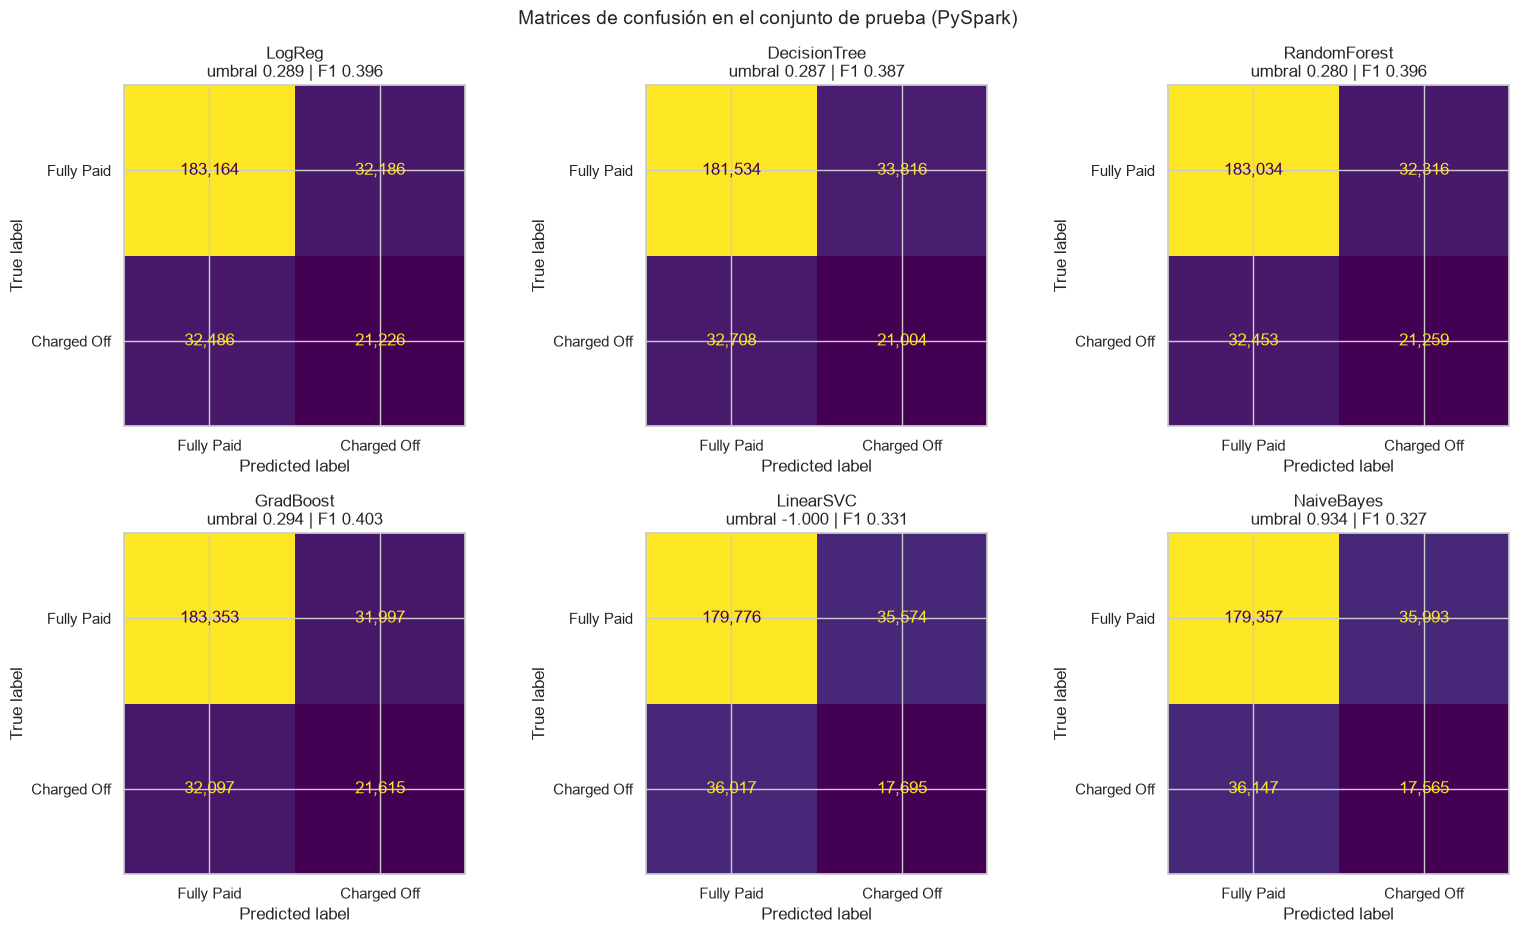

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
for ax, name in zip(axes.flat, U.MODELS):
    c = results[name]["test"]["confusion"]
    cm = np.array([[c["tn"], c["fp"]], [c["fn"], c["tp"]]])
    ConfusionMatrixDisplay(cm, display_labels=["Fully Paid", "Charged Off"]).plot(ax=ax, colorbar=False, values_format=",")
    ax.set_title(f"{name}\numbral {results[name]['threshold']:.3f} | F1 {results[name]['test']['f1']:.3f}")
fig.suptitle("Matrices de confusión en el conjunto de prueba (PySpark)", fontsize=14)
plt.tight_layout()
plt.show()

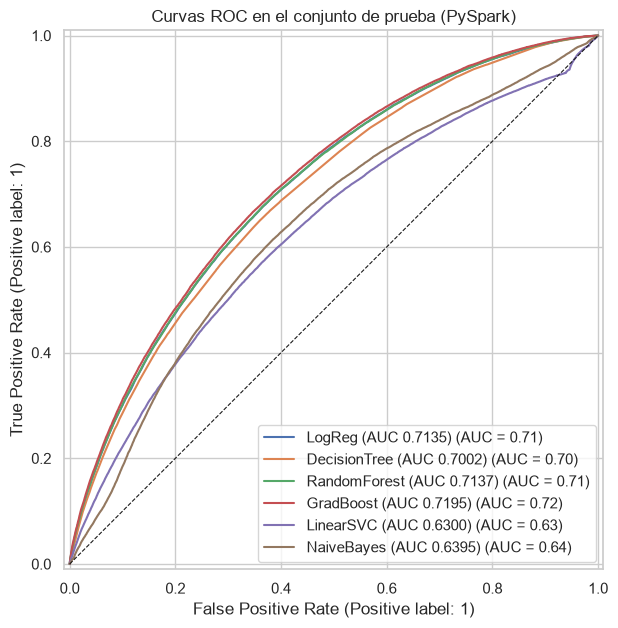

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))
for name in U.MODELS:
    RocCurveDisplay.from_predictions(test_local[U.TARGET], test_local[name], ax=ax,
                                     name=f"{name} (AUC {auc_check.loc[name].iloc[1]:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("Curvas ROC en el conjunto de prueba (PySpark)")
plt.show()

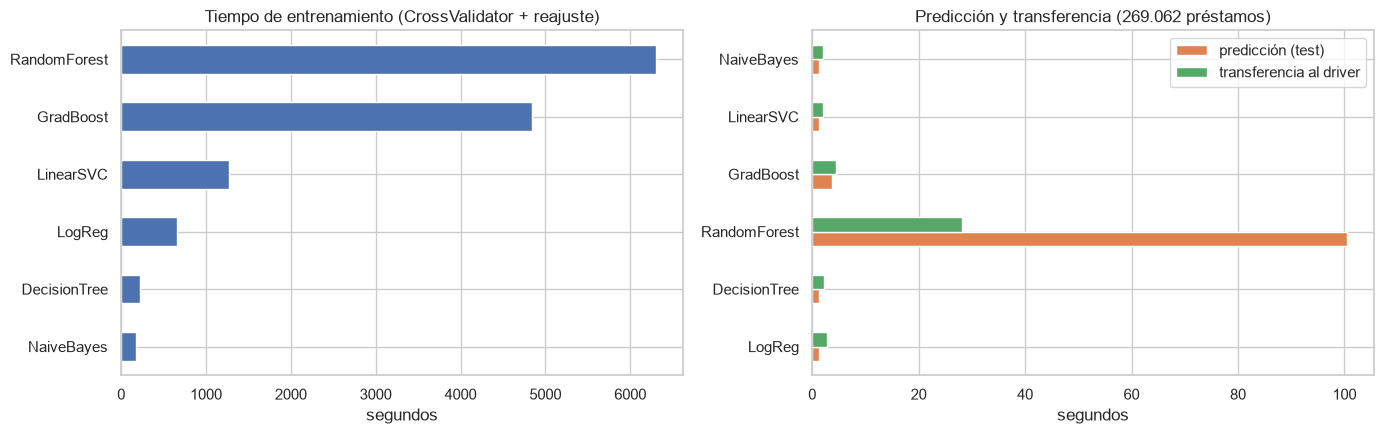

,entrenamiento con validación cruzada,predicción (test),transferencia al driver,preprocesamiento (en cada sesión)
LogReg,662.92,1.36,2.72,112.85
DecisionTree,219.31,1.34,2.28,164.86
RandomForest,6306.32,100.52,28.21,165.35
GradBoost,4845.50,3.69,4.41,103.41
LinearSVC,1268.88,1.29,2.04,177.14
NaiveBayes,174.22,1.31,2.03,112.36


In [12]:
tt = pd.DataFrame({"entrenamiento con validación cruzada": {n: r["train_time_s"] for n, r in results.items()},
                   "predicción (test)": {n: r["predict_time_s"] for n, r in results.items()},
                   "transferencia al driver": {n: r["transfer_time_s"] for n, r in results.items()},
                   "preprocesamiento (en cada sesión)": {n: r["preprocess_time_s"] for n, r in results.items()}})
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tt["entrenamiento con validación cruzada"].sort_values().plot.barh(ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("segundos")
axes[0].set_title("Tiempo de entrenamiento (CrossValidator + reajuste)")
tt[["predicción (test)", "transferencia al driver"]].plot.barh(ax=axes[1], color=["#DD8452", "#55A868"])
axes[1].set_xlabel("segundos")
axes[1].set_title("Predicción y transferencia (269.062 préstamos)")
plt.tight_layout()
plt.show()
tt.round(2)

## 4.6 Efecto de las condiciones de ejecución en el rendimiento

Este experimento justifica las dos decisiones de ejecución del capítulo y responde a la pregunta de la reflexión sobre el efecto de las condiciones obligatorias. Se mide con dos modelos de referencia, entrenados sobre el conjunto de entrenamiento completo:

**Particiones y `cacheNodeIds`.** Un `RandomForestClassifier(numTrees=10, maxDepth=10)` en cuatro variantes:

* 400 particiones, que son las que hereda la unión con la partición común por `spark.sql.shuffle.partitions=400`;
* 12 particiones, una por núcleo;
* cada una de las dos anteriores, con y sin `cacheNodeIds`.

**Caché.** Una `LogisticRegression(regParam=1e-5, maxIter=10)` con el DataFrame cacheado frente a sin cachear. Sin caché, cada una de las 10 iteraciones del optimizador vuelve a leer el CSV y a recalcular el preprocesamiento.

In [13]:
spark = U.spark_session()
res400 = U.spark_preprocess(spark)                      # 400 particiones heredadas de la unión
t400 = res400["train"]
t12 = t400.coalesce(U.SPARK_MODEL_PARTITIONS).persist(StorageLevel.MEMORY_AND_DISK)
t12.count()

def timed(fn, reps=1):
    ts = []
    for _ in range(reps):
        t0 = time.time()
        fn()
        ts.append(time.time() - t0)
    return float(np.mean(ts))

rf = lambda **kw: RandomForestClassifier(featuresCol=feat, labelCol=lab, numTrees=10, maxDepth=10, maxBins=32,
                                         seed=U.SEED, **kw)
exp_rf = pd.Series({
    "400 particiones": timed(lambda: rf().fit(t400)),
    "400 particiones + cacheNodeIds": timed(lambda: rf(cacheNodeIds=True).fit(t400)),
    "12 particiones": timed(lambda: rf().fit(t12)),
    "12 particiones + cacheNodeIds (configuración usada)": timed(lambda: rf(cacheNodeIds=True).fit(t12)),
}, name="tiempo de ajuste (s)").to_frame()
exp_rf["aceleración vs. 400 particiones"] = exp_rf.iloc[0, 0] / exp_rf.iloc[:, 0]
exp_rf.round(2)

,tiempo de ajuste (s),aceleración vs. 400 particiones
400 particiones,377.07,1.00
400 particiones + cacheNodeIds,380.87,0.99
12 particiones,47.15,8.00
12 particiones + cacheNodeIds (configuración usada),36.39,10.36


In [14]:
lr10 = LogisticRegression(featuresCol=feat, labelCol=lab, elasticNetParam=0.0, standardization=False,
                          regParam=1e-5, maxIter=10)
raw_train = U.spark_load_model_frame(spark).filter(F.col("split") == "train")
uncached = res400["model"].transform(U.spark_clip_log(raw_train, res400["bounds"])).select("id", lab, feat)
exp_cache = pd.Series({
    "cacheado, 12 particiones (configuración usada)": timed(lambda: lr10.fit(t12), reps=3),
    "cacheado, 400 particiones": timed(lambda: lr10.fit(t400), reps=3),
    "sin caché (recalcula desde el CSV en cada pasada)": timed(lambda: lr10.fit(uncached), reps=1),
}, name="tiempo de ajuste (s)").to_frame()
exp_cache["relativo a la configuración usada"] = exp_cache.iloc[:, 0] / exp_cache.iloc[0, 0]
t12.unpersist()
U.spark_shutdown(spark)
exp_cache.round(2)

,tiempo de ajuste (s),relativo a la configuración usada
"cacheado, 12 particiones (configuración usada)",8.38,1.00
"cacheado, 400 particiones",51.33,6.13
sin caché (recalcula desde el CSV en cada pasada),117.13,13.98


**Interpretación del experimento**

El número de particiones es el factor dominante del rendimiento en modo local. Con las 400 particiones que hereda la unión con la partición común, a través de `spark.sql.shuffle.partitions=400`, el bosque de referencia tarda ocho veces más que con 12 particiones, y la regresión logística seis veces más. En un único equipo con 12 núcleos lógicos, 400 particiones de unas 2700 filas obligan a lanzar 400 tareas en cada pasada sobre los datos y, en el caso de los árboles, a crear y combinar 400 agregadores de estadísticas mediante `treeAggregate`. El costo de coordinación supera así al cómputo útil. Ese valor es razonable en un clúster con cientos de núcleos, pero no en una sola máquina. Con 12 particiones, `cacheNodeIds` reduce el tiempo en un 23 % adicional, hasta una aceleración total de 10,4 veces; con 400 particiones no aporta ninguna mejora, porque el costo por tarea oculta el ahorro. El caché, por último, resulta imprescindible: sin él, cada una de las diez iteraciones de la regresión logística vuelve a leer el CSV de 1,7 GB y a repetir el preprocesamiento, y el ajuste se vuelve catorce veces más lento. En una validación cruzada con cien iteraciones por ajuste, esa penalización se multiplicaría.

## 4.7 Resumen del capítulo

En PySpark, el mejor modelo vuelve a ser gradient boosting (`GBTClassifier`, 100 iteraciones y profundidad 5), con un AUC de 0,7195, un AUC-PR de 0,387 y un F1 de 0,403. Coincide con scikit-learn tanto en el modelo ganador como en sus hiperparámetros. Le siguen el bosque aleatorio (0,7137) y la regresión logística (0,7135). La concordancia entre entornos es notable. La regresión logística obtiene el mismo AUC con cuatro decimales, aunque la validación cruzada eligió un `regParam` distinto en cada entorno ($10^{-4}$ frente a $10^{-6}$), lo que indica que el AUC de validación es prácticamente plano en esa región de regularización. En los modelos de árboles, las diferencias son de 0,002 a 0,003 puntos de AUC, atribuibles a la discretización en `maxBins=32` y a la aleatoriedad del *bootstrap*; su significancia se evalúa en el capítulo 5. El AUC que calcula `BinaryClassificationEvaluator` con 1000 umbrales coincide con el exacto hasta la cuarta cifra decimal en los seis modelos, y el bosque de profundidad 15 vuelve a ser el único con una brecha apreciable entre entrenamiento y prueba (0,774 frente a 0,714).

LinearSVC constituye la gran excepción: alcanza un AUC de 0,630 en Spark, frente a 0,461 en scikit-learn. Spark minimiza la pérdida hinge en el primal con OWL-QN y sin regularizar el intercepto, y reproduce casi exactamente la referencia primal de la sección 3.6 (0,627). Su función de decisión, sin embargo, también es negativa para todos los préstamos, de modo que con el umbral nulo no predice ningún default. La pérdida hinge sigue siendo inadecuada para este problema desbalanceado; la formulación de Spark únicamente preserva mejor el ordenamiento.

El entrenamiento completo con validación cruzada tomó 3 h 45 min, frente a 2 h 57 min en scikit-learn. PySpark solo fue más rápido en gradient boosting (81 frente a 125 minutos) y, marginalmente, en LinearSVC. En la regresión logística fue 26 veces más lento (11 minutos frente a 25 segundos) y en Naive Bayes 14 veces más lento. Con un único equipo y datos que caben en memoria, cada pasada de Spark paga costos fijos de planificación, serialización y coordinación. En los algoritmos que realizan muchas pasadas baratas, como las cien iteraciones de L-BFGS de la regresión logística, ese costo domina; en los que realizan pocas pasadas costosas, como la construcción de árboles del boosting, el paralelismo interno de Spark lo compensa, mientras que `GradientBoostingClassifier` trabaja en un solo hilo.

Debe advertirse que los tiempos de la regresión logística, el árbol y el bosque se midieron en una ejecución en la que las JVM de los modelos anteriores no se cerraban por completo y retenían memoria sin consumir CPU. El error se corrigió en `U.spark_shutdown` antes de entrenar los tres modelos restantes, cuyo primer intento, en el caso de GBT, había fallado precisamente por agotamiento de la memoria del sistema. Los tiempos de esos tres modelos podrían estar ligeramente sobrestimados por la presión de memoria, en especial el del bosque.

In [15]:
timings = json.loads((U.DATA_DIR / "timings.json").read_text(encoding="utf-8"))
timings["preprocesamiento_pyspark_por_sesion"] = {n: r["preprocess_time_s"] for n, r in results.items()}
timings["experimento_particiones_rf"] = exp_rf.iloc[:, 0].to_dict()
timings["experimento_cache_lr"] = exp_cache.iloc[:, 0].to_dict()
_ = (U.DATA_DIR / "timings.json").write_text(json.dumps(timings, indent=2, ensure_ascii=False), encoding="utf-8")